# Understanding Empirical Mode Decomposition (EMD)

This exploratory notebook was created to understand how Empirical Mode Decomposition works on a synthetic signal before applying it to EEG signals in the schizophrenia detection pipeline.

## Purpose

The goal of this notebook is to:
- understand the principle of EMD,
- decompose a non-stationary synthetic signal into Intrinsic Mode Functions (IMFs),
- visualize the extracted modes,
- explore Hilbert-Huang time-frequency analysis.

In [ ]:
import emd
import numpy as np

In [ ]:
sample_rate = 1000
seconds = 10
num_samples = sample_rate*seconds

time_vect = np.linspace(0, seconds, num_samples)

freq = 5
nonlinearity_deg = .25
nonlinearity_phi = -np.pi/4
x = emd.simulate.abreu2010(freq, nonlinearity_deg, nonlinearity_phi, sample_rate, seconds)
x += np.cos(2*np.pi*1*time_vect)

In [ ]:
imfs = emd.sift.sift(x)

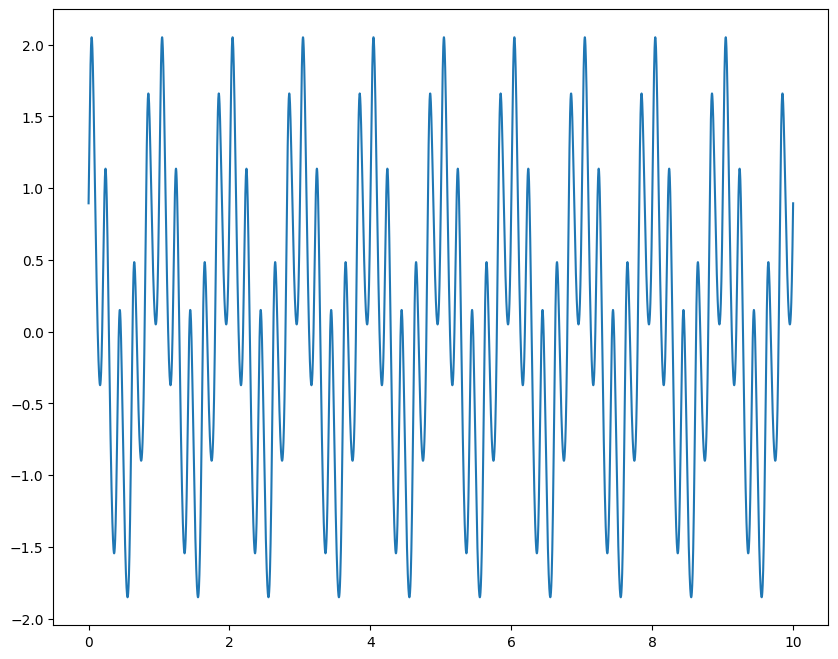

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.plot(time_vect, x, label="Signal original")

In [ ]:
IP, IF, IA = emd.spectra.frequency_transform(imfs, sample_rate, 'hilbert')

In [ ]:
freq_range = (0, 10, 100)
f, hht = emd.spectra.hilberthuang(IF, IA, freq_range, sum_time=False)

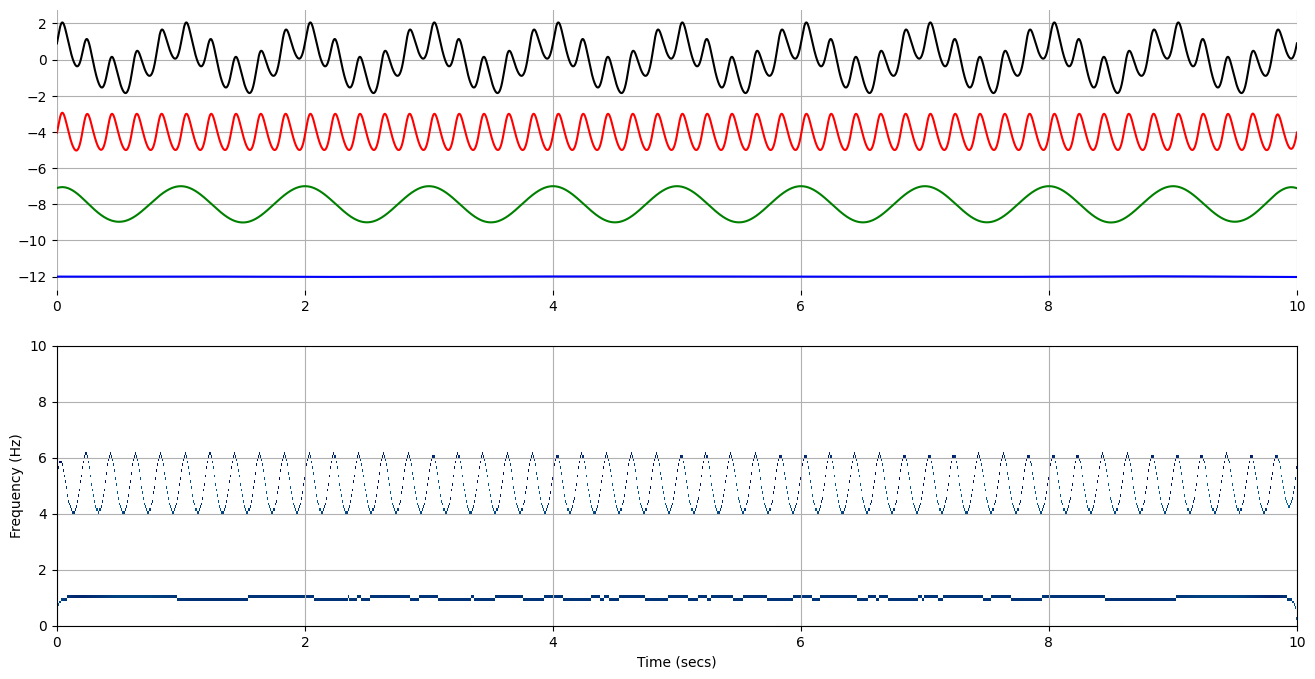

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16, 8))
plt.subplot(211, frameon=False)
plt.plot(time_vect, x, 'k')
plt.plot(time_vect, imfs[:, 0]-4, 'r')
plt.plot(time_vect, imfs[:, 1]-8, 'g')
plt.plot(time_vect, imfs[:, 2]-12, 'b')
plt.xlim(time_vect[0], time_vect[-1])
plt.grid(True)
plt.subplot(212)
plt.pcolormesh(time_vect, f, hht, cmap='ocean_r')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (secs)')
plt.grid(True)
plt.show()

In [ ]:
from PyEMD import EMD


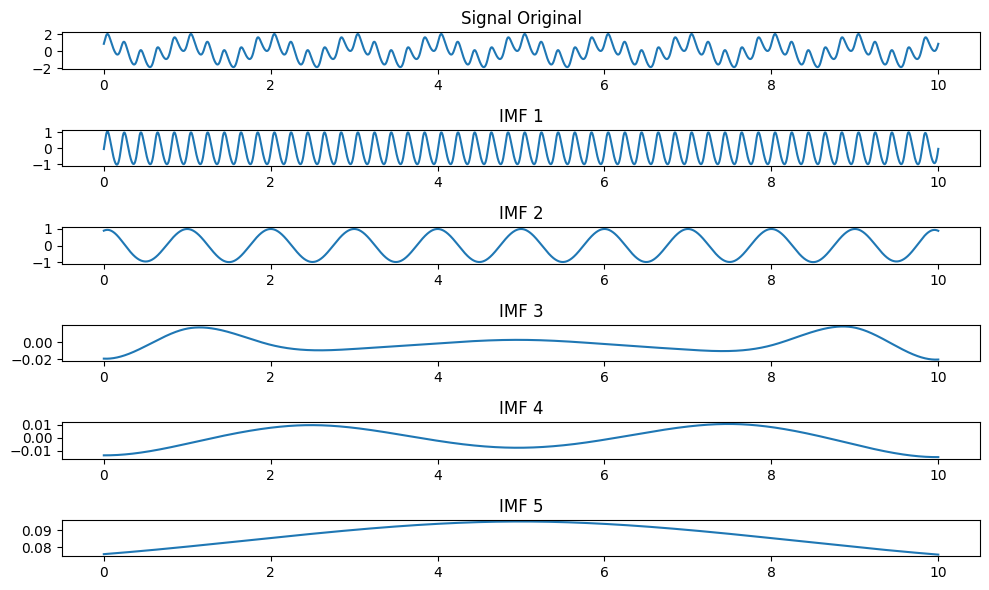

In [ ]:

emd = EMD()
imfs = emd.emd(x)

num_imfs = imfs.shape[0]
fig, axs = plt.subplots(num_imfs + 1, 1, figsize=(10, (num_imfs + 1)))

axs[0].plot(time_vect, x)
axs[0].set_title("Signal Original")

for i in range(num_imfs):
    axs[i + 1].plot(time_vect, imfs[i])
    axs[i + 1].set_title(f"IMF {i + 1}")

plt.tight_layout()
plt.show()
